In [43]:
import cv2
import os
import xml.etree.ElementTree as ET

from sklearn.svm import SVC
from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

import shutil
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf

In [44]:
# Path ke folder dataset
dataset_dir = "DATASETS/Sudah Labelling"

# List semua kategori
columns = ['Botol Kaca', 'Botol Plastik', 'Kardus']

# Buat daftar untuk menyimpan semua file dan kategori biner
merged_unique = []
allColumn_lists = []

# Loop melalui setiap kategori
for category in columns:
    category_path = os.path.join(dataset_dir, category)
    if os.path.isdir(category_path):
        # Ambil semua file .jpg dalam kategori ini
        category_files = [f for f in os.listdir(category_path) if f.endswith('.jpg') and os.path.isfile(os.path.join(category_path, f))]
        
        if category_files:  # Hanya tambahkan jika ada file
            # Tambahkan file ke merged_unique
            merged_unique.extend(category_files)
            # Tambahkan daftar file kategori ke allColumn_lists
            allColumn_lists.append(category_files)
        else:
            print(f"Warning: Folder '{category}' kosong atau tidak memiliki file .jpg.")
            allColumn_lists.append([])  # Tambahkan daftar kosong jika folder kosong
    else:
        print(f"Error: Folder '{category}' tidak ditemukan di '{dataset_dir}'.")
        allColumn_lists.append([])  # Tambahkan daftar kosong jika folder tidak ditemukan

# Hilangkan duplikasi di merged_unique
merged_unique = list(set(merged_unique))

# Buat kolom biner untuk setiap kategori
all_bin_columns = []
for column in allColumn_lists:
    bin_column = []
    for merged_file in merged_unique:
        if merged_file in column:
            bin_column.append(1)  # Cocok
        else:
            bin_column.append(0)  # Tidak cocok
    all_bin_columns.append(bin_column)

# Cek apakah jumlah kategori cocok
if len(columns) != len(all_bin_columns):
    print("Error: Jumlah kolom tidak cocok dengan jumlah kategori!")
    print(f"columns: {len(columns)}, all_bin_columns: {len(all_bin_columns)}")
    exit()

# Buat DataFrame untuk memetakan file dan kategori biner
imageMap_train = pd.DataFrame({'Filenames': merged_unique})
for i, category in enumerate(columns):
    imageMap_train[category] = all_bin_columns[i]

# Atur agar semua kolom terlihat saat dicetak
pd.set_option('display.max_columns', None)

# Tampilkan DataFrame hasil
print(imageMap_train.head(10))


      Filenames  Botol Kaca  Botol Plastik  Kardus
0    R_3855.jpg           1              0       0
1    R_3865.jpg           1              0       0
2  Image_49.jpg           0              1       0
3    R_2157.jpg           0              0       1
4   Image_4.jpg           0              1       0
5    R_3858.jpg           1              0       0
6    R_3863.jpg           1              0       0
7    R_2165.jpg           0              0       1
8    R_2169.jpg           0              0       1
9    R_2173.jpg           0              0       1


In [45]:
import os
from collections import defaultdict

# Path ke folder dataset
dataset_dir = "DATASETS/Sudah Labelling"

# Dictionary untuk menyimpan jumlah sampel per kategori
category_counts = defaultdict(int)

# Loop melalui setiap kategori di dalam folder
for category in os.listdir(dataset_dir):
    category_path = os.path.join(dataset_dir, category)
    if os.path.isdir(category_path):  # Pastikan itu folder
        # Hitung jumlah file JPG dalam kategori ini
        num_files = len([f for f in os.listdir(category_path) if f.endswith('.jpg') and os.path.isfile(os.path.join(category_path, f))])
        category_counts[category] += num_files

# Hitung total sampel dan jumlah unik
total_samples = sum(category_counts.values())
unique_samples = len(category_counts)

# Cetak hasil
print("Number of Samples:")
print("-------------------------")
for category, count in category_counts.items():
    print(f"{category} = {count}")
print("--------------------------")
print(f"Total number of samples = {total_samples}")
print(f"Total number of Unique samples = {unique_samples}")

Number of Samples:
-------------------------
Botol Kaca = 18
Botol Plastik = 22
Kardus = 25
--------------------------
Total number of samples = 65
Total number of Unique samples = 3


In [46]:
# List of labeled categories
columns = ['Botol Kaca', 'Botol Plastik', 'Kardus']

# Input directory
input_dir = 'DATASETS/Sudah Labelling'

In [47]:
# Direktori dataset input
dataset_dir = "DATASETS/Sudah Labelling"

# Direktori dataset output
output_dir = "Dataset Output"

# Ukuran output gambar yang di-crop
IMAGE_SIZE = (32, 128)

# Fungsi untuk memproses satu file XML
def process_xml_file(category_path, xml_filename, output_category_dir):
    # Parse file XML
    xml_path = os.path.join(category_path, xml_filename)
    tree = ET.parse(xml_path)
    root = tree.getroot()

    # Baca gambar yang sesuai
    img_filename = root.find('filename').text
    img_path = os.path.join(category_path, img_filename)
    img = cv2.imread(img_path)
    
    if img is None:
        print(f"Error reading image {img_path}. Skipping.")
        return

    # Mask untuk menghindari overlap objek
    mask = np.ones(img.shape[:2], dtype=bool)

    # Proses setiap objek dalam file XML
    objects = list(root.iter('object'))
    
    # Proses objek positif
    for i, obj in enumerate(objects):
        # Ambil bounding box
        bndbox = obj.find('bndbox')
        x1 = max(0, int(bndbox.find('xmin').text))
        y1 = max(0, int(bndbox.find('ymin').text))
        x2 = min(img.shape[1], int(bndbox.find('xmax').text))
        y2 = min(img.shape[0], int(bndbox.find('ymax').text))

        # Pastikan ukuran crop valid
        if x2 > x1 and y2 > y1:
            # Crop dan resize objek
            crop_img = img[y1:y2, x1:x2]
            crop_img = cv2.resize(crop_img, IMAGE_SIZE)

            # Simpan dengan nama file sesuai kategori
            output_filename = f'{img_filename.split(".")[0]}_{category}_{i}.jpg'
            output_path = os.path.join(output_category_dir, output_filename)
            cv2.imwrite(output_path, crop_img)

            # Perbarui mask untuk menghindari overlap
            mask[y1:y2, x1:x2] = False

    # Generate gambar negatif
    num_negatives = len(objects)  # Jumlah negatif = jumlah objek
    attempts = 0
    generated_negatives = 0

    while generated_negatives < num_negatives and attempts < 100:
        # Pilih lokasi acak untuk crop
        y = np.random.randint(0, max(1, img.shape[0] - IMAGE_SIZE[1]))
        x = np.random.randint(0, max(1, img.shape[1] - IMAGE_SIZE[0]))

        # Jika area tidak overlap dengan objek, simpan
        crop_area = mask[y:y + IMAGE_SIZE[1], x:x + IMAGE_SIZE[0]]
        if crop_area.size == IMAGE_SIZE[0] * IMAGE_SIZE[1] and crop_area.all():
            crop_img = img[y:y + IMAGE_SIZE[1], x:x + IMAGE_SIZE[0]]
            crop_img = cv2.resize(crop_img, IMAGE_SIZE)
            output_filename = f'{img_filename.split(".")[0]}_Negative_{generated_negatives}.jpg'
            output_path = os.path.join(output_category_dir, output_filename)
            cv2.imwrite(output_path, crop_img)
            generated_negatives += 1
        
        attempts += 1

In [48]:
os.makedirs(output_dir, exist_ok=True)

# Hitung total file yang akan diproses
total_files = 0
for category in os.listdir(dataset_dir):
    category_path = os.path.join(dataset_dir, category)
    if os.path.isdir(category_path):
        total_files += len([f for f in os.listdir(category_path) if f.endswith('.xml')])

# Variabel untuk tracking progress
processed_files = 0

# Loop melalui setiap kategori di dalam folder input
for category in os.listdir(dataset_dir):
    category_path = os.path.join(dataset_dir, category)
    if os.path.isdir(category_path):  # Pastikan ini folder
        # Direktori output per kategori
        output_category_dir = os.path.join(output_dir, category)
        os.makedirs(output_category_dir, exist_ok=True)

        # Proses setiap file XML dalam folder kategori
        for filename in os.listdir(category_path):
            if filename.endswith(".xml"):
                process_xml_file(category_path, filename, output_category_dir)
                
                # Update dan tampilkan progress
                processed_files += 1
                print(f"Progress: {processed_files}/{total_files} files processed ({processed_files/total_files*100:.2f}%)")

Progress: 1/66 files processed (1.52%)
Progress: 2/66 files processed (3.03%)
Progress: 3/66 files processed (4.55%)
Progress: 4/66 files processed (6.06%)
Progress: 5/66 files processed (7.58%)
Progress: 6/66 files processed (9.09%)
Progress: 7/66 files processed (10.61%)
Progress: 8/66 files processed (12.12%)
Progress: 9/66 files processed (13.64%)
Progress: 10/66 files processed (15.15%)
Progress: 11/66 files processed (16.67%)
Progress: 12/66 files processed (18.18%)
Progress: 13/66 files processed (19.70%)
Progress: 14/66 files processed (21.21%)
Progress: 15/66 files processed (22.73%)
Progress: 16/66 files processed (24.24%)
Progress: 17/66 files processed (25.76%)
Progress: 18/66 files processed (27.27%)
Progress: 19/66 files processed (28.79%)
Progress: 20/66 files processed (30.30%)
Progress: 21/66 files processed (31.82%)
Progress: 22/66 files processed (33.33%)
Progress: 23/66 files processed (34.85%)
Progress: 24/66 files processed (36.36%)
Progress: 25/66 files processed

In [49]:
from sklearn.model_selection import train_test_split

def reorganize_and_split_dataset(input_dir, output_base_dir, train_ratio, val_ratio):
    """
    Reorganize dataset by separating negative images and split into train/val/test sets
    
    Args:
    input_dir: Directory containing the original categorized images
    output_base_dir: Base directory for the reorganized dataset
    train_ratio: Ratio of training set (default: 0.7)
    val_ratio: Ratio of validation set (default: 0.15)
    test_ratio will be the remaining (1 - train_ratio - val_ratio)
    """
    
    # Buat direktori output utama
    os.makedirs(output_base_dir, exist_ok=True)
    
    # Buat struktur direktori
    splits = ['train', 'val', 'test']
    categories = [d for d in os.listdir(input_dir) if os.path.isdir(os.path.join(input_dir, d))]
    
    for split in splits:
        for category in categories + ['negative']:
            os.makedirs(os.path.join(output_base_dir, split, category), exist_ok=True)
    
    # Dictionary untuk menyimpan file per kategori
    files_by_category = {category: [] for category in categories}
    negative_files = []
    
    # Pisahkan file negatif dan positif
    for category in categories:
        category_path = os.path.join(input_dir, category)
        for filename in os.listdir(category_path):
            file_path = os.path.join(category_path, filename)
            if 'Negative' in filename:
                negative_files.append((file_path, filename))
            else:
                files_by_category[category].append((file_path, filename))
                
    # Split dan pindahkan file untuk setiap kategori
    for category, files in files_by_category.items():
        # Split dataset
        train_files, temp_files = train_test_split(files, train_size=train_ratio, random_state=42)
        val_ratio_adjusted = val_ratio / (1 - train_ratio)
        val_files, test_files = train_test_split(temp_files, train_size=val_ratio_adjusted, random_state=42)
        
        # Pindahkan file
        for file_path, filename in train_files:
            shutil.copy2(file_path, os.path.join(output_base_dir, 'train', category, filename))
            
        for file_path, filename in val_files:
            shutil.copy2(file_path, os.path.join(output_base_dir, 'val', category, filename))
            
        for file_path, filename in test_files:
            shutil.copy2(file_path, os.path.join(output_base_dir, 'test', category, filename))
    
    # Split dan pindahkan file negatif
    train_neg, temp_neg = train_test_split(negative_files, train_size=train_ratio, random_state=42)
    val_ratio_adjusted = val_ratio / (1 - train_ratio)
    val_neg, test_neg = train_test_split(temp_neg, train_size=val_ratio_adjusted, random_state=42)
    
    # Pindahkan file negatif
    for file_path, filename in train_neg:
        shutil.copy2(file_path, os.path.join(output_base_dir, 'train', 'negative', filename))
        
    for file_path, filename in val_neg:
        shutil.copy2(file_path, os.path.join(output_base_dir, 'val', 'negative', filename))
        
    for file_path, filename in test_neg:
        shutil.copy2(file_path, os.path.join(output_base_dir, 'test', 'negative', filename))

def print_dataset_stats(output_base_dir):
    """
    Print statistics about the dataset split
    """
    splits = ['train', 'val', 'test']
    print("\nDataset Statistics:")
    print("-" * 50)
    
    for split in splits:
        print(f"\n{split.upper()} Set:")
        split_path = os.path.join(output_base_dir, split)
        total_images = 0
        
        for category in os.listdir(split_path):
            category_path = os.path.join(split_path, category)
            num_images = len(os.listdir(category_path))
            total_images += num_images
            print(f"{category}: {num_images} images")
        
        print(f"Total {split} images: {total_images}")
    
    print("\n" + "-" * 50)

In [50]:
input_dir = "Dataset Output"  # Direktori hasil dari script sebelumnya
output_base_dir = "Final Dataset"  # Direktori untuk dataset final

print("Memulai reorganisasi dan split dataset...")

# Jalankan fungsi utama
reorganize_and_split_dataset(
    input_dir=input_dir,
    output_base_dir=output_base_dir,
    train_ratio=0.8,  # 70% training
    val_ratio=0.10    # 15% validation, 15% testing
)

# Tampilkan statistik
print_dataset_stats(output_base_dir)

print("\nPemrosesan selesai!")


Memulai reorganisasi dan split dataset...



Dataset Statistics:
--------------------------------------------------

TRAIN Set:
Botol Kaca: 16 images
Botol Plastik: 34 images
Kardus: 20 images
negative: 51 images
Total train images: 121

VAL Set:
Botol Kaca: 2 images
Botol Plastik: 4 images
Kardus: 3 images
negative: 10 images
Total val images: 19

TEST Set:
Botol Kaca: 2 images
Botol Plastik: 5 images
Kardus: 3 images
negative: 11 images
Total test images: 21

--------------------------------------------------

Pemrosesan selesai!


In [51]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array

def load_dataset(base_path, subset='train'):
    """
    Load dataset images and labels from the specified path
    
    Args:
    base_path: Path to the base directory of the dataset
    subset: 'train', 'val', or 'test'
    
    Returns:
    images: numpy array of images
    labels: dictionary with labels for each category
    """
    subset_path = os.path.join(base_path, subset)
    categories = [d for d in os.listdir(subset_path) if os.path.isdir(os.path.join(subset_path, d))]
    
    images = []
    labels = {category: [] for category in categories}
    
    print(f"\nLoading {subset} dataset...")
    total_images = 0
    
    # Load images and labels for each category
    for category in categories:
        category_path = os.path.join(subset_path, category)
        print(f"Loading {category} images...")
        
        for img_name in os.listdir(category_path):
            img_path = os.path.join(category_path, img_name)
            try:
                # Load and preprocess image
                img = load_img(img_path, target_size=(64, 128))
                img_array = img_to_array(img)
                img_array = img_array / 255.0  # Normalize to [0,1]
                
                images.append(img_array)
                
                # Create one-hot encoded labels
                for cat in categories:
                    labels[cat].append(1 if cat == category else 0)
                    
                total_images += 1
                
            except Exception as e:
                print(f"Error loading image {img_path}: {e}")
                continue
    
    # Convert to numpy arrays
    images = np.array(images)
    labels = {k: np.array(v) for k, v in labels.items()}
    
    return images, labels

In [52]:
def visualize_dataset(images, labels, categories, num_samples=5):
    """
    Visualize random samples from each category in the dataset
    
    Args:
    images: numpy array of images
    labels: dictionary with labels for each category
    categories: list of category names
    num_samples: number of samples to show per category
    """
    num_categories = len(categories)
    fig, axes = plt.subplots(num_categories, num_samples, figsize=(15, 3*num_categories))
    
    for i, category in enumerate(categories):
        # Get indices of images for this category
        category_indices = np.where(labels[category] == 1)[0]
        
        # Randomly select images
        selected_indices = np.random.choice(category_indices, 
                                          size=min(num_samples, len(category_indices)), 
                                          replace=False)
        
        for j, idx in enumerate(selected_indices):
            if num_categories == 1:
                ax = axes[j]
            else:
                ax = axes[i, j]
                
            ax.imshow(images[idx])
            ax.axis('off')
            if j == 0:
                ax.set_title(f'{category}', size=10)
    
    plt.tight_layout()
    plt.show()

def print_dataset_stats(images, labels, categories):
    """
    Print statistics about the dataset
    """
    print("\nDataset Statistics:")
    print("-" * 50)
    print(f"Total Images: {len(images)}")
    
    for category in categories:
        count = np.sum(labels[category])
        percentage = (count / len(images)) * 100
        print(f"{category}: {int(count)} images ({percentage:.1f}%)")
    
    print("-" * 50)
    print(f"Image Shape: {images.shape}")
    print(f"Value Range: [{images.min():.3f}, {images.max():.3f}]")

Loading dataset...

Loading train dataset...
Loading Botol Kaca images...
Loading Botol Plastik images...
Loading Kardus images...
Loading negative images...

Dataset Statistics:
--------------------------------------------------
Total Images: 121
Botol Kaca: 16 images (13.2%)
Botol Plastik: 34 images (28.1%)
Kardus: 20 images (16.5%)
negative: 51 images (42.1%)
--------------------------------------------------
Image Shape: (121, 64, 128, 3)
Value Range: [0.000, 1.000]

Visualizing dataset samples...


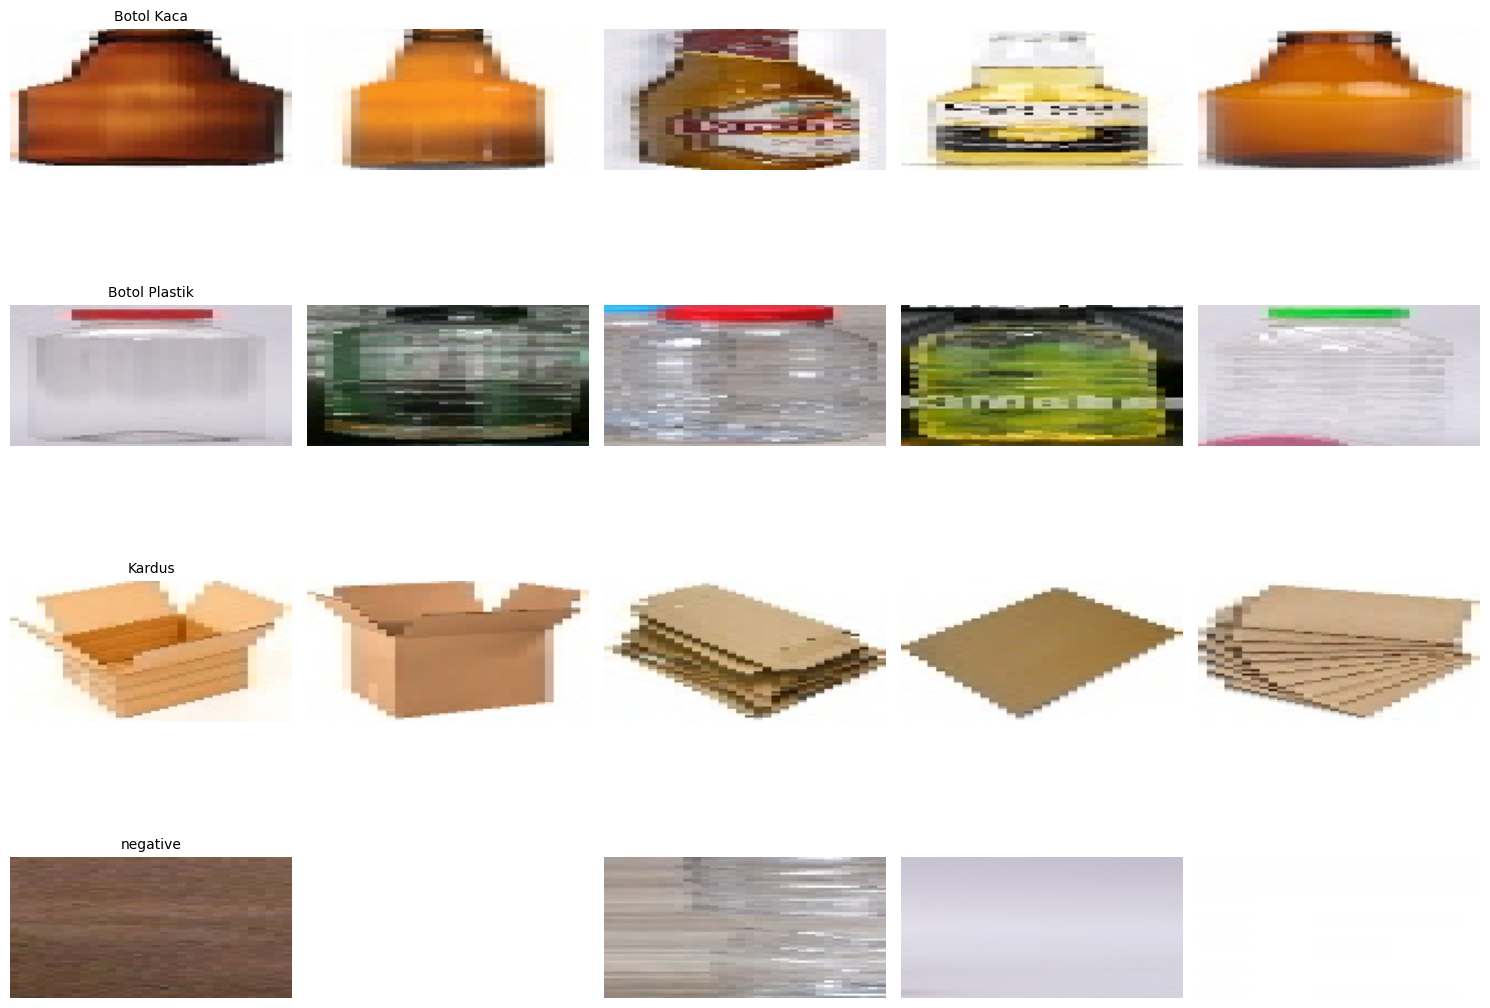


Loading validation set...

Loading val dataset...
Loading Botol Kaca images...
Loading Botol Plastik images...
Loading Kardus images...
Loading negative images...

Dataset Statistics:
--------------------------------------------------
Total Images: 19
Botol Kaca: 2 images (10.5%)
Botol Plastik: 4 images (21.1%)
Kardus: 3 images (15.8%)
negative: 10 images (52.6%)
--------------------------------------------------
Image Shape: (19, 64, 128, 3)
Value Range: [0.000, 1.000]

Loading test set...

Loading test dataset...
Loading Botol Kaca images...
Loading Botol Plastik images...
Loading Kardus images...
Loading negative images...

Dataset Statistics:
--------------------------------------------------
Total Images: 21
Botol Kaca: 2 images (9.5%)
Botol Plastik: 5 images (23.8%)
Kardus: 3 images (14.3%)
negative: 11 images (52.4%)
--------------------------------------------------
Image Shape: (21, 64, 128, 3)
Value Range: [0.000, 1.000]


In [53]:
base_path = 'Final Dataset'
    
# Load dataset
print("Loading dataset...")
train_images, train_labels = load_dataset(base_path, subset='train')

# Get categories (excluding 'negative')
categories = [k for k in train_labels.keys() if k != 'negative']
categories.append('negative')  # Add negative at the end

# Print dataset statistics
print_dataset_stats(train_images, train_labels, categories)

# Visualize dataset
print("\nVisualizing dataset samples...")
visualize_dataset(train_images, train_labels, categories)

# Optional: Load validation and test sets
print("\nLoading validation set...")
val_images, val_labels = load_dataset(base_path, subset='val')
print_dataset_stats(val_images, val_labels, categories)

print("\nLoading test set...")
test_images, test_labels = load_dataset(base_path, subset='test')
print_dataset_stats(test_images, test_labels, categories)

# Model

In [54]:
def create_cnn_model(num_classes):
    """
    Membuat arsitektur model CNN
    """
    model = tf.keras.models.Sequential([
        # Input layer        
        # First Convolutional Block
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape = (64, 128, 3), padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Dropout(0.25),
        
        # Second Convolutional Block
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Dropout(0.25),
        
        # Third Convolutional Block
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Dropout(0.25),
        
        # Dense tf.keras.Layers
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(512, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    
    return model

In [55]:
def load_and_prepare_data(base_path):
    """
    Load and prepare dataset for training
    """
    # Load dataset using previous function
    train_images, train_labels = load_dataset(base_path, 'train')
    val_images, val_labels = load_dataset(base_path, 'val')
    test_images, test_labels = load_dataset(base_path, 'test')
    
    # Get category names
    categories = list(train_labels.keys())
    
    # Convert labels to format suitable for training
    train_y = np.array([np.argmax([train_labels[cat][i] for cat in categories]) 
                       for i in range(len(train_images))])
    val_y = np.array([np.argmax([val_labels[cat][i] for cat in categories]) 
                     for i in range(len(val_images))])
    test_y = np.array([np.argmax([test_labels[cat][i] for cat in categories]) 
                      for i in range(len(test_images))])
    
    return (train_images, train_y), (val_images, val_y), (test_images, test_y), categories

In [56]:
def visualize_prediction(image, true_label, pred_probs, categories):
    """
    Visualize image and its prediction probabilities in a table format
    """
    # Create figure with two subplots
    fig = plt.figure(figsize=(15, 6))
    
    # Plot image
    ax1 = plt.subplot(1, 2, 1)
    ax1.imshow(image)
    ax1.axis('off')
    ax1.set_title('Test Image')
    
    # Create table data
    data = {
        'Category': categories,
        'Probability': pred_probs.round(4)
    }
    df = pd.DataFrame(data)
    
    # Plot table
    ax2 = plt.subplot(1, 2, 2)
    ax2.axis('off')
    table = ax2.table(cellText=df.values,
                     colLabels=df.columns,
                     cellLoc='center',
                     loc='center',
                     colColours=['#f2f2f2']*2)
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.2, 1.5)
    
    # Highlight true label
    true_idx = categories.index(categories[true_label])
    cells = table._cells
    cells[(true_idx+1, 0)].set_facecolor('#90EE90')
    
    plt.tight_layout()
    plt.show()

In [57]:
base_path = 'Final Dataset'
batch_size = 32
epochs = 50

# Load and prepare data
(train_images, train_y), (val_images, val_y), (test_images, test_y), categories = load_and_prepare_data(base_path)

# Create and compile model
model = create_cnn_model(len(categories))
model.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

# Model summary
model.summary()


Loading train dataset...
Loading Botol Kaca images...
Loading Botol Plastik images...
Loading Kardus images...
Loading negative images...

Loading val dataset...
Loading Botol Kaca images...
Loading Botol Plastik images...
Loading Kardus images...
Loading negative images...

Loading test dataset...
Loading Botol Kaca images...
Loading Botol Plastik images...
Loading Kardus images...
Loading negative images...


c:\Users\WatsonNick\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 64, 128, 32)    │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64, 128, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 16, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 16, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 8, 16, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 8, 16, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │     8,389,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,618,692 (32.88 MB)

 Trainable params: 8,616,708 (32.87 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [58]:
# Train model
print("\nTraining model...")
history = model.fit(train_images, train_y,
                    batch_size=batch_size,
                    epochs=epochs,
                    validation_data=(val_images, val_y),
                    verbose=1)

# Evaluate model
test_loss, test_acc = model.evaluate(test_images, test_y, verbose=0)
print(f"\nTest accuracy: {test_acc:.4f}")


Training model...
Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 528ms/step - accuracy: 0.3571 - loss: 2.2560 - val_accuracy: 0.2105 - val_loss: 1.3055
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 356ms/step - accuracy: 0.7103 - loss: 0.8277 - val_accuracy: 0.5263 - val_loss: 1.1318
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 360ms/step - accuracy: 0.7969 - loss: 0.6050 - val_accuracy: 0.5263 - val_loss: 1.1524
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 380ms/step - accuracy: 0.9361 - loss: 0.2148 - val_accuracy: 0.5263 - val_loss: 1.3013
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 434ms/step - accuracy: 0.9090 - loss: 0.2220 - val_accuracy: 0.5263 - val_loss: 1.7432
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 417ms/step - accuracy: 0.9486 - loss: 0.1226 - val_accuracy: 0.5263 - val_loss: 2.4449
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 360ms/step - accuracy: 0.9680 - loss: 0.1120 - val_accuracy: 0.5263 - val_loss: 2.9793
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 321ms/step - accuracy: 0.9816 - loss: 0.0705 - val_accuracy

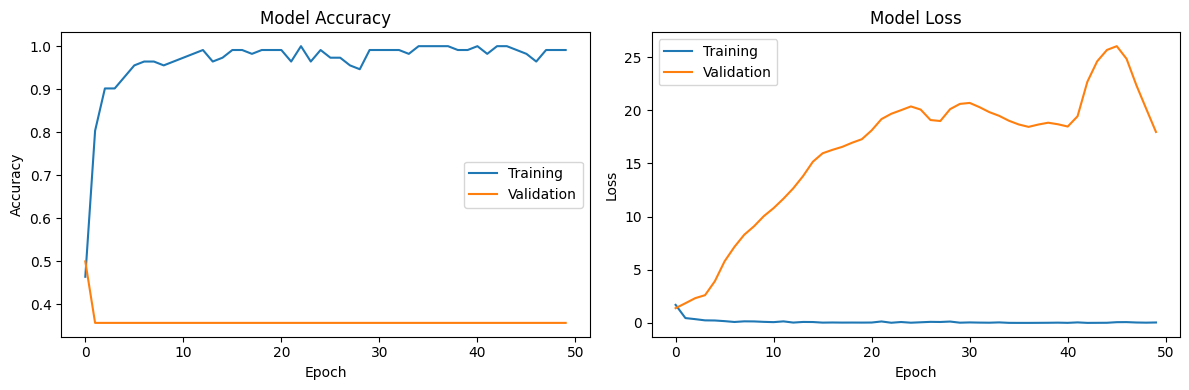

In [42]:
# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


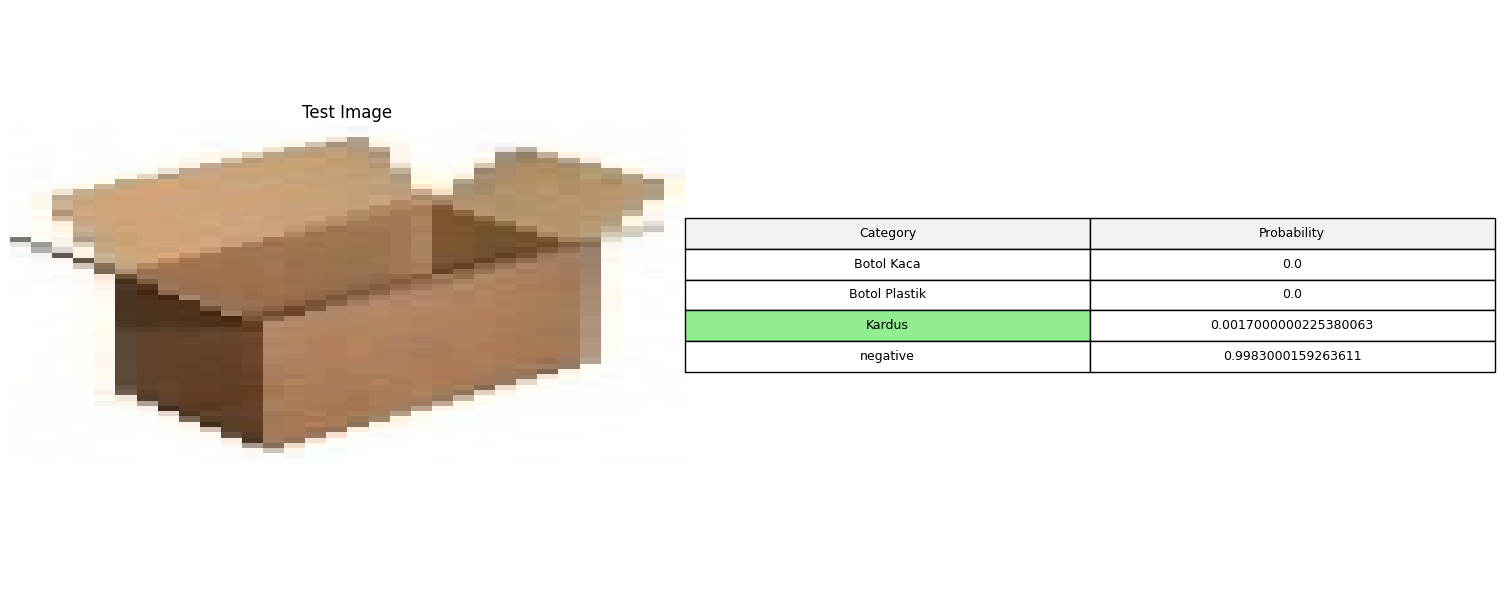

In [64]:
# Make predictions on a random test image
random_idx = np.random.randint(len(test_images))
test_image = test_images[random_idx]
true_label = test_y[random_idx]

# Get prediction probabilities
pred_probs = model.predict(np.expand_dims(test_image, axis=0))[0]

# Visualize prediction
visualize_prediction(test_image, true_label, pred_probs, categories)